# Import Libraries


This section imports the required libraries for data extraction and data warehouse creation.

In [1]:
import pandas as pd
from sqlalchemy import create_engine

# Database Connection
This section creates connections to the source OLTP database and the destination Data Warehouse database.

In [2]:


username = "root"
password = "8354"
host = "127.0.0.1"
port = 3306

srcDatabase = "sakila"
dstDatabase = "movie_rental"

srcConnection_string = f"mysql+pymysql://{username}:{password}@{host}:{port}/{srcDatabase}"
dstConnection_string = f"mysql+pymysql://{username}:{password}@{host}:{port}/{dstDatabase}"

engine1 = create_engine(srcConnection_string)
engine2 = create_engine(dstConnection_string)

# Extract OLTP Tables
This section extracts data from the OLTP database tables.

In [3]:


film = pd.read_sql("SELECT * FROM film", con=engine1)
category = pd.read_sql("SELECT * FROM category", con=engine1)
film_category = pd.read_sql("SELECT * FROM film_category", con=engine1)

store = pd.read_sql("SELECT * FROM store", con=engine1)
staff = pd.read_sql("SELECT * FROM staff", con=engine1)

customer = pd.read_sql("SELECT * FROM customer", con=engine1)

rental = pd.read_sql("SELECT * FROM rental", con=engine1)
payment = pd.read_sql("SELECT * FROM payment", con=engine1)
inventory = pd.read_sql("SELECT * FROM inventory", con=engine1)

address = pd.read_sql("SELECT * FROM address", con=engine1)
city = pd.read_sql("SELECT * FROM city", con=engine1)
country = pd.read_sql("SELECT * FROM country", con=engine1)

# Create dim_film
This section creates the Film Dimension table.

In [4]:


dim_film = pd.DataFrame({
    "film_id": film["film_id"],
    "title": film["title"],
    "rating": film["rating"],
    "rental_rate": film["rental_rate"],
    "rental_duration": film["rental_duration"],
    "release_year": film["release_year"]
})
print(dim_film.isnull().sum())

dim_film.index.name = "film_key"

dim_film.to_sql(
    "dim_film",
    con=engine2,
    if_exists="replace",
    index=True
)

film_id            0
title              0
rating             0
rental_rate        0
rental_duration    0
release_year       0
dtype: int64


1000

# Create dim_category
This section creates the Category Dimension table.

In [5]:


dim_category = pd.DataFrame({
    "category_id": category["category_id"],
    "category_name": category["name"]
})
print(dim_category.isnull().sum())

dim_category.index.name = "category_key"

dim_category.to_sql(
    "dim_category",
    con=engine2,
    if_exists="replace",
    index=True
)

category_id      0
category_name    0
dtype: int64


16

# Create bridge_film_category
This section creates the bridge table between films and categories.

In [6]:


dim_film_dw = pd.read_sql(
    "SELECT film_id, film_key FROM dim_film",
    con=engine2
)

dim_category_dw = pd.read_sql(
    "SELECT category_id, category_key FROM dim_category",
    con=engine2
)

bridge_film_category = (
    film_category
    .merge(dim_film_dw, on="film_id", how="left")
    .merge(dim_category_dw, on="category_id", how="left")
)

bridge_film_category = bridge_film_category[[
    "film_key",
    "category_key"
]]

bridge_film_category.to_sql(
    "bridge_film_category",
    con=engine2,
    if_exists="replace",
    index=False
)

1000

# Create dim_store
This section creates the Store Dimension table.

In [7]:


store_raw = (
    store
    .merge(
        staff[["staff_id", "first_name", "last_name"]],
        left_on="manager_staff_id",
        right_on="staff_id",
        how="left"
    )
    .merge(
        address[["address_id", "city_id"]],
        on="address_id",
        how="left"
    )
    .merge(
        city[["city_id", "country_id", "city"]],
        on="city_id",
        how="left"
    )
    .merge(
        country[["country_id", "country"]],
        on="country_id",
        how="left"
    )
)

dim_store = pd.DataFrame({
    "store_id": store_raw["store_id"],
    "manager_name":
        store_raw["first_name"] + " " +
        store_raw["last_name"],
    "city": store_raw["city"],
    "country": store_raw["country"]
    
})
print(dim_store.isnull().sum())
dim_store.index.name = "store_key"

dim_store.to_sql(
    "dim_store",
    con=engine2,
    if_exists="replace",
    index=True
)

store_id        0
manager_name    0
city            0
country         0
dtype: int64


2

# Create dim_customer
This section creates the Customer Dimension table.

In [8]:


customer_raw = (
    customer
    .merge(
        address[["address_id", "city_id"]],
        on="address_id",
        how="left"
    )
    .merge(
        city[["city_id", "country_id", "city"]],
        on="city_id",
        how="left"
    )
    .merge(
        country[["country_id", "country"]],
        on="country_id",
        how="left"
    )
)

dim_customer = pd.DataFrame({
    "customer_id": customer_raw["customer_id"],
    "full_name":
        customer_raw["first_name"] + " " +
        customer_raw["last_name"],
    "email": customer_raw["email"],
    "city": customer_raw["city"],
    "country": customer_raw["country"]
})
print(dim_customer.isnull().sum())

dim_customer.index.name = "customer_key"

dim_customer.to_sql(
    "dim_customer",
    con=engine2,
    if_exists="replace",
    index=True
)

customer_id    0
full_name      0
email          0
city           0
country        0
dtype: int64


599

# Create dim_staff
This section creates the Staff Dimension table.

In [9]:


dim_staff = pd.DataFrame({
    "staff_id": staff["staff_id"],
    "full_name":
        staff["first_name"] + " " +
        staff["last_name"],
    "store_id": staff["store_id"]
})
print(dim_staff.isnull().sum())

dim_staff.index.name = "staff_key"

dim_staff.to_sql(
    "dim_staff",
    con=engine2,
    if_exists="replace",
    index=True
)

staff_id     0
full_name    0
store_id     0
dtype: int64


2

# Create dim_location
This section creates the Location Dimension table.

In [10]:


location_raw = (
    address
    .merge(
        city[["city_id", "country_id", "city"]],
        on="city_id",
        how="left"
    )
    .merge(
        country[["country_id", "country"]],
        on="country_id",
        how="left"
    )
)

dim_location = pd.DataFrame({
    "city": location_raw["city"],
    "country": location_raw["country"],
    "district": location_raw["district"]
}).drop_duplicates()
print(dim_location.isnull().sum())
dim_location.index.name = "location_key"

dim_location.to_sql(
    "dim_location",
    con=engine2,
    if_exists="replace",
    index=True
)

city        0
country     0
district    0
dtype: int64


601

# Create dim_date
This section creates the Date Dimension table to support time-based analysis.

In [20]:
all_dates = pd.concat([
    rental["rental_date"].dt.normalize(),
    payment["payment_date"].dt.normalize()
])

print("null")
print(all_dates.isnull().sum())
all_dates.dropna(inplace=True)

print("duplicated")
print(all_dates.duplicated().sum())
all_dates.drop_duplicates(inplace=True)
print(all_dates.duplicated().sum())
print(all_dates.isnull().sum())

dim_date = pd.DataFrame({
    "full_date": all_dates,
    "day_name": all_dates.dt.strftime("%A"),
    "month": all_dates.dt.strftime("%B"),
    "quarter": "Q" + all_dates.dt.quarter.astype(str),
    "year": all_dates.dt.year
})

dim_date.sort_values("full_date", inplace=True)

dim_date.index.name = "date_key"

dim_date.to_sql(
    "dim_date",
    con=engine2,
    if_exists="replace",
    index=True
)

null
0
duplicated
32047
0
0


41

# Create fact_rental_film
This section creates the Rental Fact table to analyze rental activity, rental duration, and late returns.

In [12]:


rf = (
    rental
    .merge(
        inventory[["inventory_id", "film_id", "store_id"]],
        on="inventory_id",
        how="left"
    )
    .merge(
        film[["film_id", "rental_duration"]],
        on="film_id",
        how="left"
    )
)

dim_store_dw = pd.read_sql(
    "SELECT store_id, store_key FROM dim_store",
    con=engine2
)

dim_date_dw = pd.read_sql(
    "SELECT full_date, date_key FROM dim_date",
    con=engine2
)

rf["actual_duration"] = (
    rf["return_date"] - rf["rental_date"]
).dt.days

rf["days_late"] = (
    rf["actual_duration"] - rf["rental_duration"]
).clip(lower=0)

rf["days_late"] = rf["days_late"].fillna(0)

fact_rental_film = (
    rf
    .merge(dim_film_dw, on="film_id", how="left")
    .merge(dim_store_dw, on="store_id", how="left")
    .merge(
        dim_date_dw,
        left_on=rf["rental_date"].dt.normalize(),
        right_on="full_date",
        how="left"
    )
)

fact_rental_film["rental_count"] = 1

fact_rental_film = fact_rental_film[[
    "film_key",
    "store_key",
    "date_key",
    "actual_duration",
    "days_late",
    "rental_count"
]]

fact_rental_film.rename(
    columns={
        "actual_duration": "rental_duration"
    },
    inplace=True
)

print(fact_rental_film.isnull().sum())
fact_rental_film["rental_duration"] = (
    fact_rental_film["rental_duration"].fillna(0)
)

print(fact_rental_film.isnull().sum())
fact_rental_film = fact_rental_film.astype({
    "film_key": int,
    "store_key": int,
    "date_key": int})

fact_rental_film.index.name = "rental_film_key"

fact_rental_film.to_sql(
    "fact_rental_film",
    con=engine2,
    if_exists="replace",
    index=True
)

film_key             0
store_key            0
date_key             0
rental_duration    183
days_late            0
rental_count         0
dtype: int64
film_key           0
store_key          0
date_key           0
rental_duration    0
days_late          0
rental_count       0
dtype: int64


16044

# Create fact_payment
This section creates the Payment Fact table to analyze revenue, customer payments, and staff performance.

In [13]:


pay = (
    payment
    .merge(
        rental[["rental_id", "inventory_id"]],
        on="rental_id",
        how="left"
    )
    .merge(
        inventory[["inventory_id", "film_id", "store_id"]],
        on="inventory_id",
        how="left"
    )
)

dim_customer_dw = pd.read_sql(
    "SELECT customer_id, customer_key FROM dim_customer",
    con=engine2
)

dim_staff_dw = pd.read_sql(
    "SELECT staff_id, staff_key FROM dim_staff",
    con=engine2
)

fact_payment = (
    pay
    .merge(dim_customer_dw, on="customer_id", how="left")
    .merge(dim_film_dw, on="film_id", how="left")
    .merge(dim_store_dw, on="store_id", how="left")
    .merge(dim_staff_dw, on="staff_id", how="left")
    .merge(
        dim_date_dw,
        left_on=pay["payment_date"].dt.normalize(),
        right_on="full_date",
        how="left"
    )
)

fact_payment["payment_count"] = 1

fact_payment = fact_payment[[
    "customer_key",
    "film_key",
    "store_key",
    "staff_key",
    "date_key",
    "amount",
    "payment_count"
]]
print(fact_payment.isnull().sum())
fact_payment.index.name = "payment_key"

fact_payment.to_sql(
    "fact_payment",
    con=engine2,
    if_exists="replace",
    index=True
)

customer_key     0
film_key         0
store_key        0
staff_key        0
date_key         0
amount           0
payment_count    0
dtype: int64


16044

# Create fact_store_performance
This section creates the Store Performance Fact table to analyze store rentals, revenue, and late returns over time.

In [14]:

location_dw = pd.read_sql(
    "SELECT location_key, city, country FROM dim_location",
    con=engine2
)

store_perf = (
    rf
    .groupby([
        "store_id",
        rf["rental_date"].dt.normalize()
    ])
    .agg({
        "inventory_id": "count",
        "days_late": "sum"
    })
    .reset_index()
)

store_perf.rename(columns={
    "inventory_id": "total_rentals",
    "days_late": "total_late_returns",
    "rental_date": "full_date"
}, inplace=True)

revenue = (
    pay
    .groupby([
        "store_id",
        pay["payment_date"].dt.normalize()
    ])["amount"]
    .sum()
    .reset_index()
)

revenue.rename(columns={
    "payment_date": "full_date",
    "amount": "total_revenue"
}, inplace=True)

store_location = (
    dim_store
    .merge(
        location_dw,
        on=["city", "country"],
        how="left"
    )
)

fact_store_performance = (
    store_perf
    .merge(
        revenue,
        on=["store_id", "full_date"],
        how="left"
    )
    .merge(dim_store_dw, on="store_id", how="left")
    .merge(
        store_location[["store_id", "location_key"]],
        on="store_id",
        how="left"
    )
    .merge(dim_date_dw, on="full_date", how="left")
)

fact_store_performance = fact_store_performance[[
    "store_key",
    "location_key",
    "date_key",
    "total_rentals",
    "total_revenue",
    "total_late_returns"
]]
print(fact_store_performance.isnull().sum())
fact_store_performance.index.name = "store_performance_key"

fact_store_performance.to_sql(
    "fact_store_performance",
    con=engine2,
    if_exists="replace",
    index=True
)

store_key             0
location_key          0
date_key              0
total_rentals         0
total_revenue         0
total_late_returns    0
dtype: int64


82

# Analytical Visualizations
This section creates analytical charts from the data warehouse fact tables to support business analysis and reporting.

# 1. Top 10 Most Rented Films
This chart shows the films with the highest rental frequency using the fact and dimension tables loaded into Pandas DataFrames.

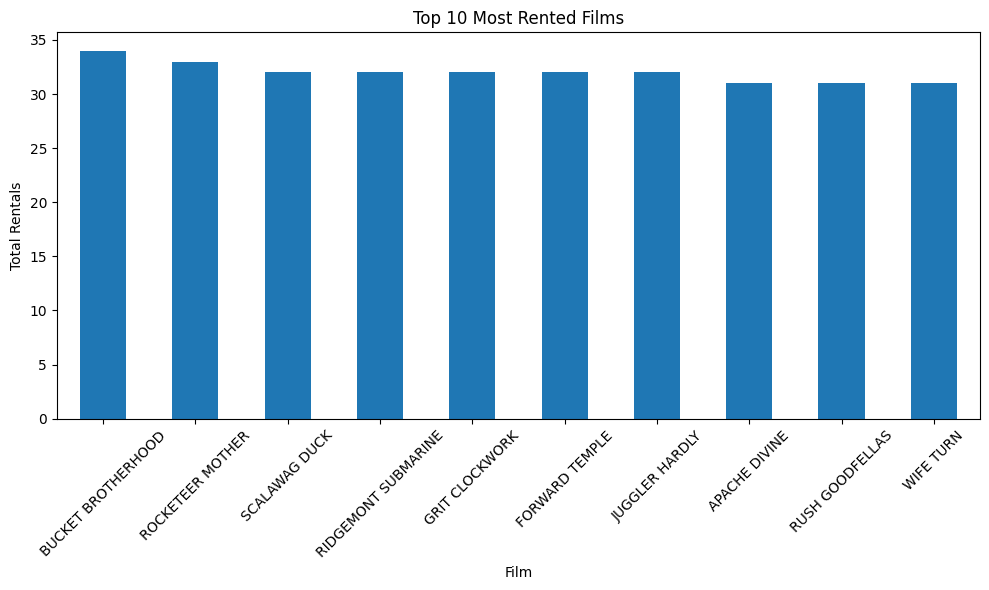

In [15]:
import matplotlib.pyplot as plt

top_films = (
    fact_rental_film
    .merge(dim_film, on="film_key")
    .groupby("title")["rental_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_films.plot(kind="bar")

plt.title("Top 10 Most Rented Films")
plt.xlabel("Film")
plt.ylabel("Total Rentals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Revenue by Store
This chart compares total revenue generated by each store.

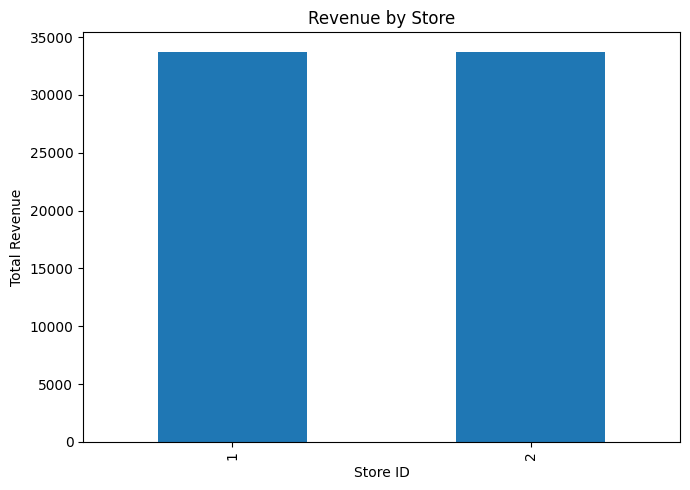

In [16]:
store_revenue = (
    fact_payment
    .merge(dim_store, on="store_key")
    .groupby("store_id")["amount"]
    .sum()
)

plt.figure(figsize=(7,5))
store_revenue.plot(kind="bar")

plt.title("Revenue by Store")
plt.xlabel("Store ID")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

# 3. Monthly Rental Trend
This chart shows rental activity changes over time by month.

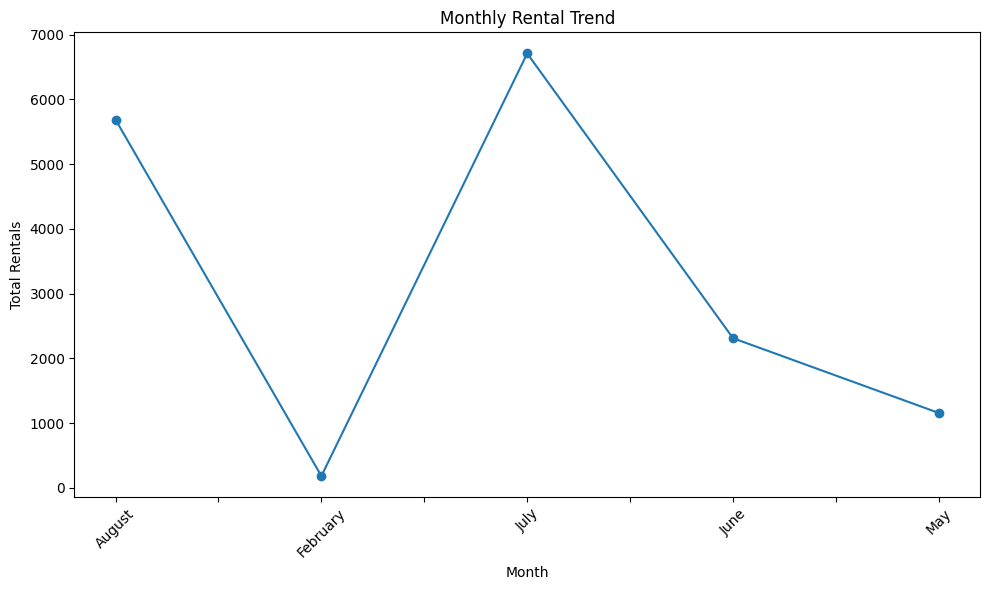

In [17]:
monthly_rentals = (
    fact_rental_film
    .merge(dim_date, on="date_key")
    .groupby("month")["rental_count"]
    .sum()
)

plt.figure(figsize=(10,6))
monthly_rentals.plot(marker='o')

plt.title("Monthly Rental Trend")
plt.xlabel("Month")
plt.ylabel("Total Rentals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Top Customers by Payments
This chart identifies customers who generated the highest revenue.

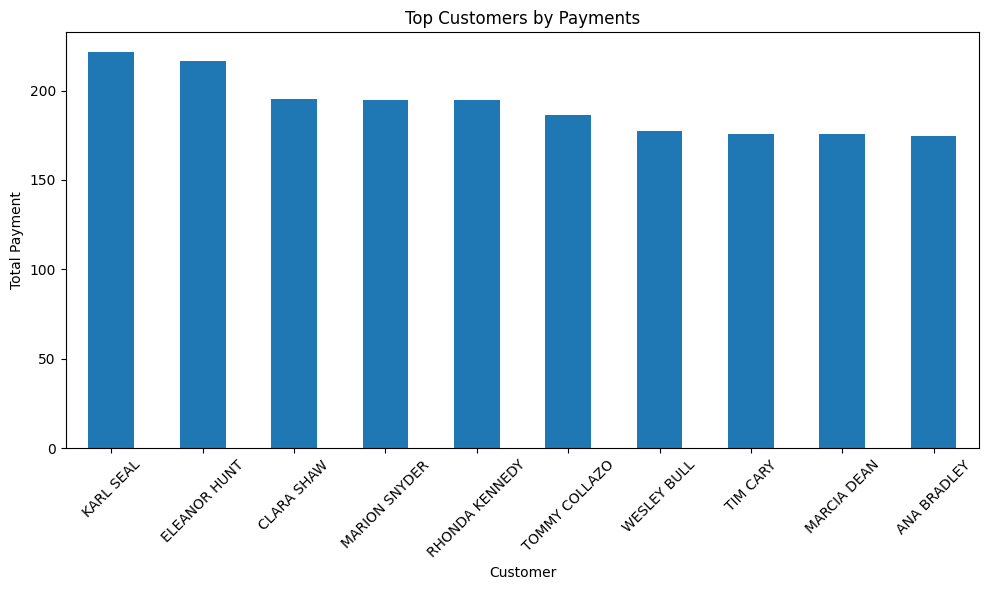

In [18]:
top_customers = (
    fact_payment
    .merge(dim_customer, on="customer_key")
    .groupby("full_name")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_customers.plot(kind="bar")

plt.title("Top Customers by Payments")
plt.xlabel("Customer")
plt.ylabel("Total Payment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Late Returns Analysis
This chart shows films with the highest late return days.

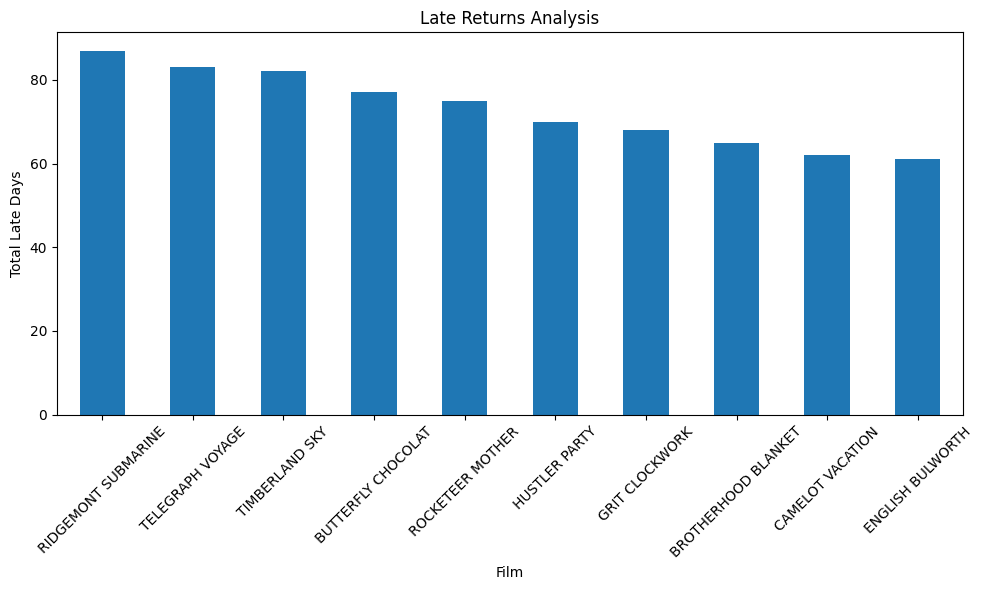

In [19]:
late_returns = (
    fact_rental_film
    .merge(dim_film, on="film_key")
    .groupby("title")["days_late"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
late_returns.plot(kind="bar")

plt.title("Late Returns Analysis")
plt.xlabel("Film")
plt.ylabel("Total Late Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()